In [93]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')



In [94]:
df = pd.read_csv(r'C:\code\MLproject1\Notebook\student_exam_performance_dataset (1).csv')

In [95]:
df.head()

,student_id,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,...,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa,pass_fail,grade_category
0,S00001,Male,17,High School,Medium,Yes,Quiet,2.98,96.5,6.05,...,1,Yes,42.8,62.4,54.8,51.8,49.1,2.44,Fail,F
1,S00002,Female,18,High School,Low,Yes,Quiet,4.45,95.7,6.96,...,0,Yes,77.9,73.5,64.4,61.6,70.1,2.79,Pass,C
2,S00003,Male,17,High School,Medium,No,Quiet,3.75,76.0,7.02,...,4,Yes,53.5,38.3,36.3,47.1,42.2,1.49,Fail,F
3,S00004,Male,18,Bachelor,Medium,Yes,Quiet,2.03,72.6,6.23,...,4,No,28.3,23.5,32.0,39.0,31.9,1.34,Fail,F
4,S00005,Male,18,Bachelor,Medium,Yes,Quiet,5.14,87.3,8.54,...,0,No,74.7,54.9,73.6,55.5,66.4,2.60,Pass,C


In [96]:
df.shape

(10000, 23)

In [97]:
df.isna().sum()

student_id                    0
gender                        0
age                           0
parental_education            0
family_income                 0
internet_access               0
study_environment             0
study_hours_per_day           0
attendance_rate               0
sleep_hours                   0
social_media_hours            0
assignment_completion_rate    0
participation_score           0
online_courses_completed      0
tutoring                      0
math_score                    0
reading_score                 0
writing_score                 0
science_score                 0
final_exam_score              0
previous_gpa                  0
pass_fail                     0
grade_category                0
dtype: int64

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  10000 non-null  object 
 1   gender                      10000 non-null  object 
 2   age                         10000 non-null  int64  
 3   parental_education          10000 non-null  object 
 4   family_income               10000 non-null  object 
 5   internet_access             10000 non-null  object 
 6   study_environment           10000 non-null  object 
 7   study_hours_per_day         10000 non-null  float64
 8   attendance_rate             10000 non-null  float64
 9   sleep_hours                 10000 non-null  float64
 10  social_media_hours          10000 non-null  float64
 11  assignment_completion_rate  10000 non-null  float64
 12  participation_score         10000 non-null  float64
 13  online_courses_completed    1000

In [99]:
df.nunique()

student_id                    10000
gender                            2
age                               4
parental_education                4
family_income                     3
internet_access                   2
study_environment                 3
study_hours_per_day             587
attendance_rate                 444
sleep_hours                     551
social_media_hours               78
assignment_completion_rate      588
participation_score             714
online_courses_completed         10
tutoring                          2
math_score                      774
reading_score                   748
writing_score                   755
science_score                   775
final_exam_score                694
previous_gpa                    340
pass_fail                         2
grade_category                    5
dtype: int64

In [100]:
num_features = [f for f in df.columns if df[f].dtype !='O']
cate_features = [f for f in df.columns if df[f].dtype =='O']
print(f"we have {len(num_features)} numerical features :{num_features}")
print(f"we have {len(cate_features)} numerical features :{cate_features}")

we have 14 numerical features :['age', 'study_hours_per_day', 'attendance_rate', 'sleep_hours', 'social_media_hours', 'assignment_completion_rate', 'participation_score', 'online_courses_completed', 'math_score', 'reading_score', 'writing_score', 'science_score', 'final_exam_score', 'previous_gpa']
we have 9 numerical features :['student_id', 'gender', 'parental_education', 'family_income', 'internet_access', 'study_environment', 'tutoring', 'pass_fail', 'grade_category']


In [101]:
df.head()

,student_id,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,...,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa,pass_fail,grade_category
0,S00001,Male,17,High School,Medium,Yes,Quiet,2.98,96.5,6.05,...,1,Yes,42.8,62.4,54.8,51.8,49.1,2.44,Fail,F
1,S00002,Female,18,High School,Low,Yes,Quiet,4.45,95.7,6.96,...,0,Yes,77.9,73.5,64.4,61.6,70.1,2.79,Pass,C
2,S00003,Male,17,High School,Medium,No,Quiet,3.75,76.0,7.02,...,4,Yes,53.5,38.3,36.3,47.1,42.2,1.49,Fail,F
3,S00004,Male,18,Bachelor,Medium,Yes,Quiet,2.03,72.6,6.23,...,4,No,28.3,23.5,32.0,39.0,31.9,1.34,Fail,F
4,S00005,Male,18,Bachelor,Medium,Yes,Quiet,5.14,87.3,8.54,...,0,No,74.7,54.9,73.6,55.5,66.4,2.60,Pass,C


In [102]:
df.columns

Index(['student_id', 'gender', 'age', 'parental_education', 'family_income',
       'internet_access', 'study_environment', 'study_hours_per_day',
       'attendance_rate', 'sleep_hours', 'social_media_hours',
       'assignment_completion_rate', 'participation_score',
       'online_courses_completed', 'tutoring', 'math_score', 'reading_score',
       'writing_score', 'science_score', 'final_exam_score', 'previous_gpa',
       'pass_fail', 'grade_category'],
      dtype='object')

In [103]:
df['total_score']=df['math_score']+df['reading_score']+df['writing_score']+df['science_score']+df['final_exam_score']+df['participation_score']
df['average']=df['total_score']/6
#df.drop(columns=['math_score','reading_score','writing_score','science_score','final_exam_score','participation_score'],axis=1,inplace=True)

In [104]:
df.columns

Index(['student_id', 'gender', 'age', 'parental_education', 'family_income',
       'internet_access', 'study_environment', 'study_hours_per_day',
       'attendance_rate', 'sleep_hours', 'social_media_hours',
       'assignment_completion_rate', 'participation_score',
       'online_courses_completed', 'tutoring', 'math_score', 'reading_score',
       'writing_score', 'science_score', 'final_exam_score', 'previous_gpa',
       'pass_fail', 'grade_category', 'total_score', 'average'],
      dtype='object')

In [109]:
reading_full = df[df['reading_score'] == 100]['student_id'].count()
reading_full

np.int64(5)

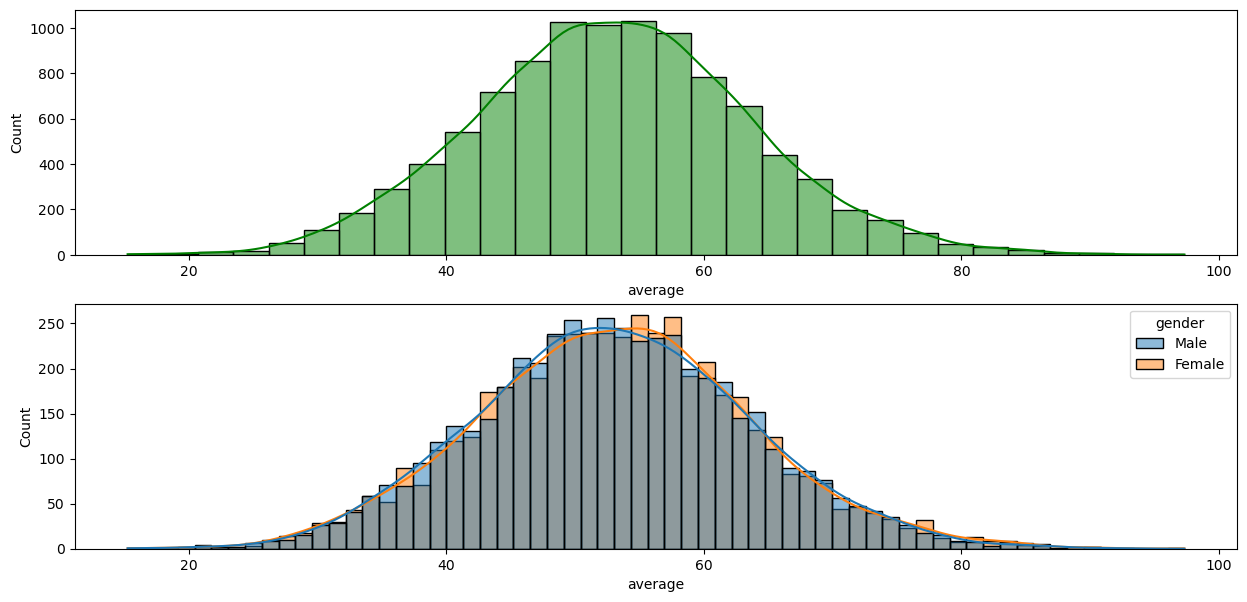

In [153]:
fig, axs = plt.subplots(2,1,figsize=(15, 7))

plt.subplot(211)
sns.histplot(data=df, x='average', bins=30, kde=True, color='g')

plt.subplot(212)
sns.histplot(data=df, x='average', kde=True, hue='gender')


plt.show()